In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Dataset load karo - Kaggle wala
train_df = pd.read_csv('../data/raw/train.csv')
val_df = pd.read_csv('../data/raw/dev.csv')
test_df = pd.read_csv('../data/raw/test.csv')

print("Train shape:", train_df.shape)
print("Val shape:", val_df.shape)
print("Test shape:", test_df.shape)
print("\nColumns:", train_df.columns.tolist())

Train shape: (87866, 9)
Val shape: (87866, 9)
Test shape: (87866, 9)

Columns: ['Unnamed: 0', 'id', 'article', 'question', 'A', 'B', 'C', 'D', 'answer']


In [15]:
train_df.head(3)

,Unnamed: 0,id,article,question,A,B,C,D,answer,avg_option_length,article_length,question_length
0,0,middle7348.txt,In the summer between my first year and second...,Before the writer came to the high school summ...,instructor,camper,student,reporter,C,1.00,345,15
1,1,middle7348.txt,In the summer between my first year and second...,How many times did the writer invite the boy t...,Once,Twice,Three times,Many times,B,1.50,345,14
2,2,middle4305.txt,A bumpkin went to a big city for the first t...,The bumpkin thought _ .,his wife was as beautiful as the young girl,his wife was more beautiful than the short fat...,the short fat woman changed to a young girl in...,He should also buy a room of that kind for his...,C,10.75,84,5


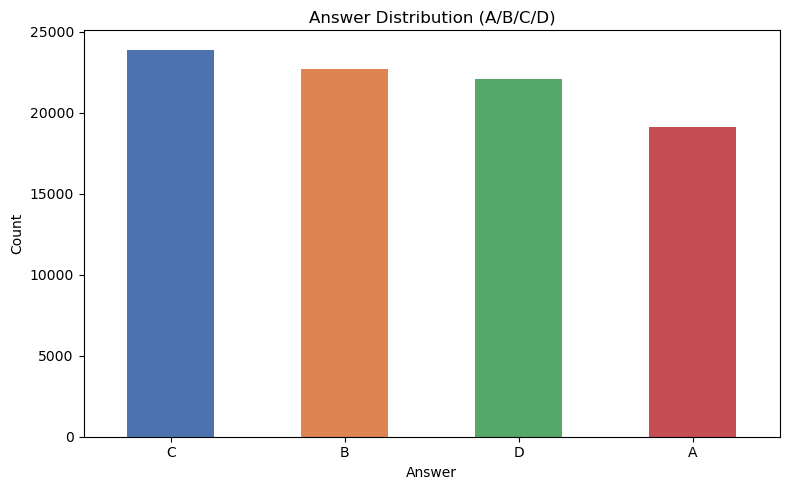

answer
C    23891
B    22726
D    22103
A    19146
Name: count, dtype: int64


In [16]:
# Answer distribution
plt.figure(figsize=(8, 5))
train_df['answer'].value_counts().plot(kind='bar', color=['#4C72B0','#DD8452','#55A868','#C44E52'])
plt.title('Answer Distribution (A/B/C/D)')
plt.xlabel('Answer')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print(train_df['answer'].value_counts())

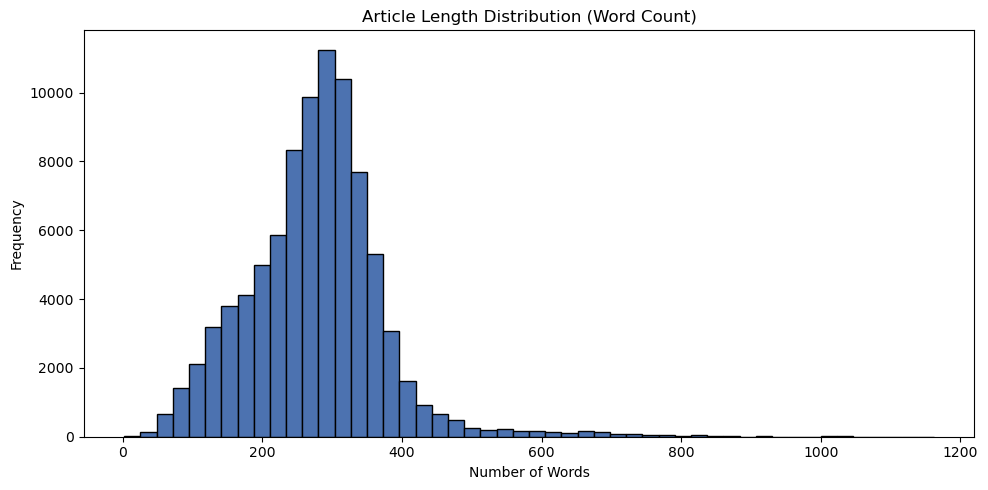

Average article length: 274.98
Max article length: 1162
Min article length: 2


In [17]:
# Article length distribution
train_df['article_length'] = train_df['article'].apply(lambda x: len(str(x).split()))

plt.figure(figsize=(10, 5))
plt.hist(train_df['article_length'], bins=50, color='#4C72B0', edgecolor='black')
plt.title('Article Length Distribution (Word Count)')
plt.xlabel('Number of Words')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

print("Average article length:", train_df['article_length'].mean().round(2))
print("Max article length:", train_df['article_length'].max())
print("Min article length:", train_df['article_length'].min())

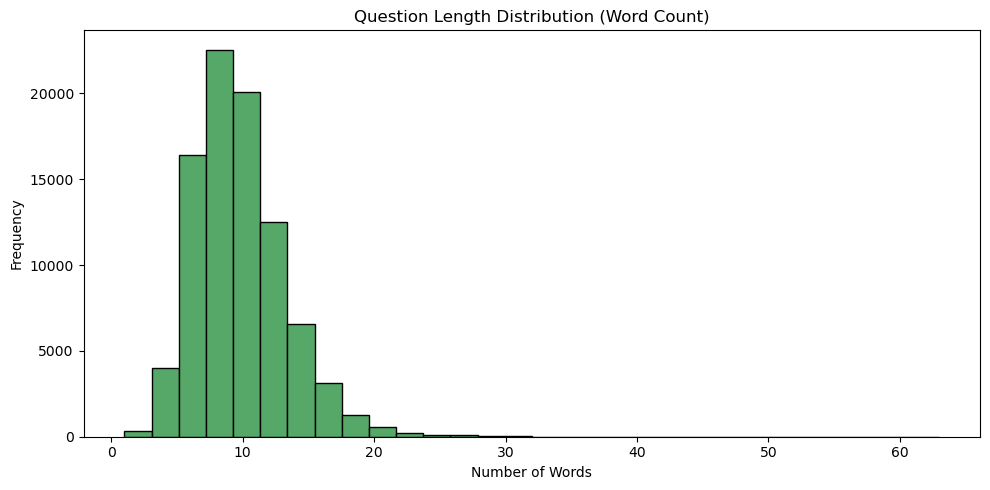

Average question length: 10.01
Max question length: 63
Min question length: 1


In [18]:
# Question length distribution
train_df['question_length'] = train_df['question'].apply(lambda x: len(str(x).split()))

plt.figure(figsize=(10, 5))
plt.hist(train_df['question_length'], bins=30, color='#55A868', edgecolor='black')
plt.title('Question Length Distribution (Word Count)')
plt.xlabel('Number of Words')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

print("Average question length:", train_df['question_length'].mean().round(2))
print("Max question length:", train_df['question_length'].max())
print("Min question length:", train_df['question_length'].min())

In [19]:
# Missing values check
print("=== Train Missing Values ===")
print(train_df.isnull().sum())

print("\n=== Val Missing Values ===")
print(val_df.isnull().sum())

print("\n=== Test Missing Values ===")
print(test_df.isnull().sum())


=== Train Missing Values ===
Unnamed: 0           0
id                   0
article              0
question             0
A                    4
B                    0
C                    1
D                    9
answer               0
avg_option_length    0
article_length       0
question_length      0
dtype: int64

=== Val Missing Values ===
Unnamed: 0    0
id            0
article       0
question      0
A             4
B             0
C             1
D             9
answer        0
dtype: int64

=== Test Missing Values ===
Unnamed: 0    0
id            0
article       0
question      0
A             4
B             0
C             1
D             9
answer        0
dtype: int64


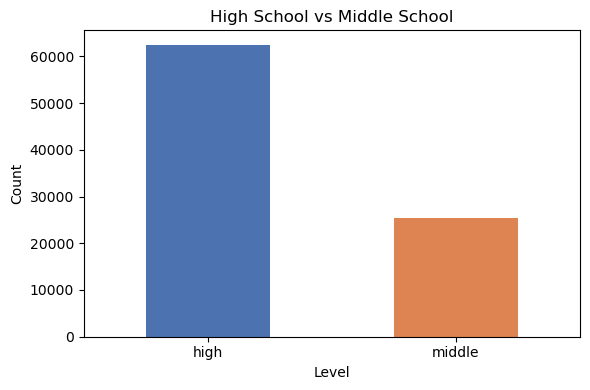

level
high      62445
middle    25421
Name: count, dtype: int64


In [20]:
# High vs Middle school
train_df['level'] = train_df['id'].apply(lambda x: 'high' if 'high' in str(x) else 'middle')

plt.figure(figsize=(6, 4))
train_df['level'].value_counts().plot(kind='bar', color=['#4C72B0', '#DD8452'])
plt.title('High School vs Middle School')
plt.xlabel('Level')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print(train_df['level'].value_counts())

In [12]:
train_df['question_length'] = train_df['question'].apply(lambda x: len(x.split()))

In [21]:
# Summary statistics
print("=== Dataset Summary ===")
print(f"Total Training Samples: {len(train_df)}")
print(f"Total Validation Samples: {len(val_df)}")
print(f"Total Test Samples: {len(test_df)}")
print(f"\nAverage Article Length: {train_df['article_length'].mean().round(2)} words")
print(f"Average Question Length: {train_df['question_length'].mean().round(2)} words")
print(f"\nAnswer Balance:")
print((train_df['answer'].value_counts(normalize=True)*100).round(2))

=== Dataset Summary ===
Total Training Samples: 87866
Total Validation Samples: 87866
Total Test Samples: 87866

Average Article Length: 274.98 words
Average Question Length: 10.01 words

Answer Balance:
answer
C    27.19
B    25.86
D    25.16
A    21.79
Name: proportion, dtype: float64


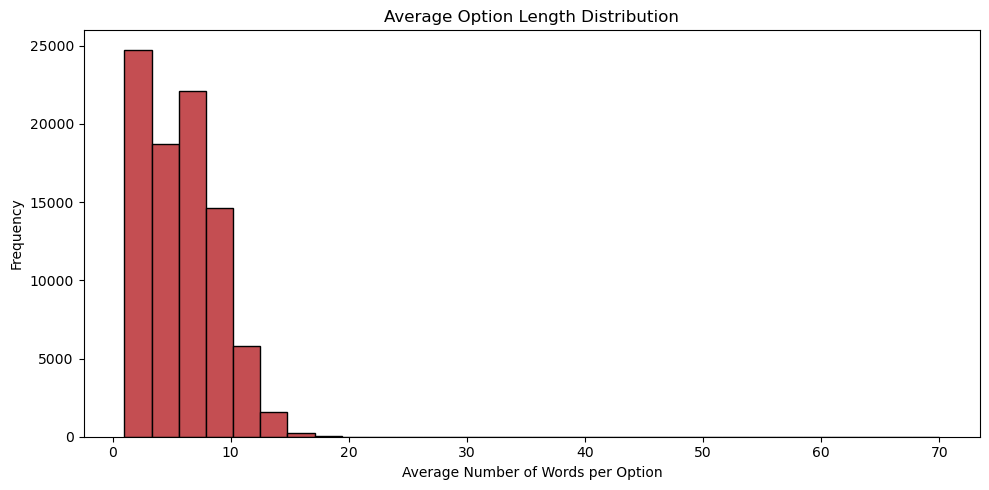

Average option length: 5.71


In [22]:
# Options length analysis
train_df['avg_option_length'] = train_df[['A','B','C','D']].apply(
    lambda row: np.mean([len(str(x).split()) for x in row]), axis=1
)

plt.figure(figsize=(10, 5))
plt.hist(train_df['avg_option_length'], bins=30, color='#C44E52', edgecolor='black')
plt.title('Average Option Length Distribution')
plt.xlabel('Average Number of Words per Option')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

print("Average option length:", train_df['avg_option_length'].mean().round(2))

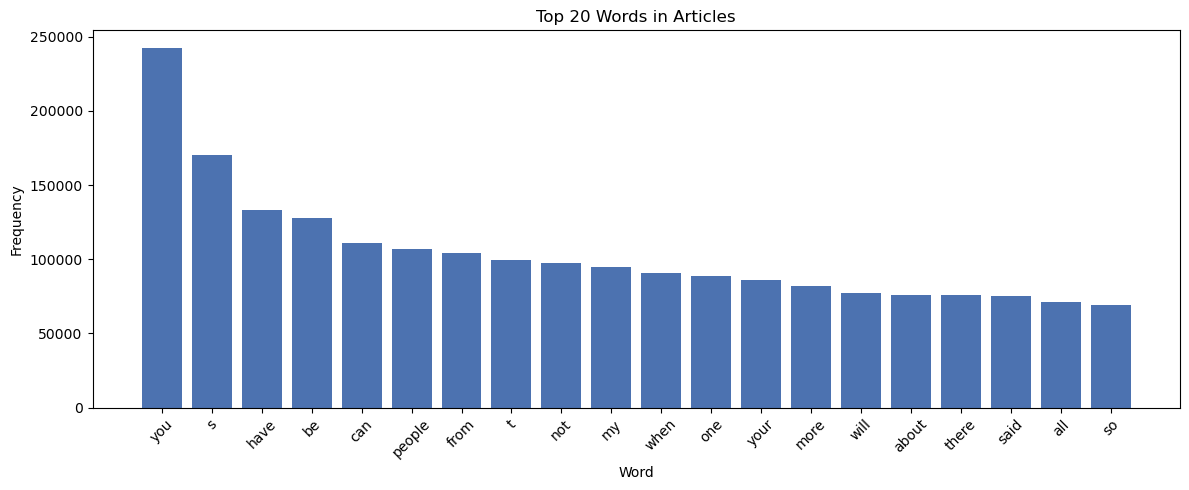

In [23]:
# top words
def get_top_words(texts, n=20):
    stopwords = {'the','a','an','is','was','are','were','in','on','at','to',
                 'of','and','or','but','it','he','she','they','we','i','his',
                 'her','their','its','this','that','with','for','as','by','had'}
    all_words = []
    for text in texts:
        words = re.findall(r'\b[a-z]+\b', str(text).lower())
        all_words.extend([w for w in words if w not in stopwords])
    return Counter(all_words).most_common(n)

top_words = get_top_words(train_df['article'])
words, counts = zip(*top_words)

plt.figure(figsize=(12, 5))
plt.bar(words, counts, color='#4C72B0')
plt.title('Top 20 Words in Articles')
plt.xlabel('Word')
plt.ylabel('Frequency')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [24]:
import subprocess
import os

os.chdir('C:/Users/mudas/race_rc_project')

result1 = subprocess.run(['git', 'add', 'notebooks/EDA.ipynb'], capture_output=True, text=True)
result2 = subprocess.run(['git', 'commit', '-m', 'add EDA notebook'], capture_output=True, text=True)
result3 = subprocess.run(['git', 'push'], capture_output=True, text=True)

print(result2.stdout)
print(result3.stdout)
print(result3.stderr)

[main 0986fee] add EDA notebook
 1 file changed, 158 insertions(+), 76 deletions(-)


To https://github.com/mudassirs52/race_rc_project.git
   8cd8bd1..0986fee  main -> main



In [27]:
import subprocess
import os

os.chdir('C:/Users/mudas/race_rc_project')

result1 = subprocess.run(['git', 'add', '.'], capture_output=True, text=True)
result2 = subprocess.run(['git', 'commit', '-m', 'add Model A unsupervised, semi-supervised and ensemble'], capture_output=True, text=True)
result3 = subprocess.run(['git', 'push'], capture_output=True, text=True)

print(result2.stdout)
print(result3.stdout)
print(result3.stderr)


[main a172967] add Model A unsupervised, semi-supervised and ensemble
 18 files changed, 1812 insertions(+), 28 deletions(-)
 create mode 100644 .ipynb_checkpoints/EDA-checkpoint.ipynb
 create mode 100644 EDA.ipynb
 create mode 100644 data/processed/X_test.npy
 create mode 100644 data/processed/X_train.npy
 create mode 100644 data/processed/X_val.npy
 create mode 100644 data/processed/label_encoder.pkl
 create mode 100644 data/processed/vocab.pkl
 create mode 100644 data/processed/y_test.npy
 create mode 100644 data/processed/y_train.npy
 create mode 100644 data/processed/y_val.npy
 create mode 100644 notebooks/.ipynb_checkpoints/EDA-checkpoint.ipynb
 create mode 100644 notebooks/.ipynb_checkpoints/model_a_training-checkpoint.ipynb
 create mode 100644 notebooks/.ipynb_checkpoints/preprocessing_run-checkpoint.ipynb
 create mode 100644 src/.ipynb_checkpoints/model_a_train-checkpoint.py
 create mode 100644 src/.ipynb_checkpoints/preprocessing-checkpoint.py


remote: error: Trace: 57a94a12

In [3]:
# just for checking that all files are same or not 
import os
for f in ['train.csv', 'dev.csv', 'test.csv']:
    size = os.path.getsize(f'../data/raw/{f}')
    print(f"{f}: {size/1024/1024:.2f} MB")

train.csv: 148.80 MB
dev.csv: 148.80 MB
test.csv: 148.80 MB
